# 👩‍💻 Fine-Tune a Pre-Trained Model on a New Dataset

## 📋 Overview
In this lab, you will explore the powerful concept of transfer learning by fine-tuning a pre-trained Convolutional Neural Network (CNN) on a new dataset. By leveraging models such as ResNet18 or VGG16 that are pre-trained on ImageNet, you'll efficiently adapt them to a new image classification task with limited data. This technique is widely used in industry to build powerful image classifiers without requiring extensive computational resources or massive datasets.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Load and modify pre-trained CNN models using PyTorch
- Adapt pre-trained models for new tasks through strategic layer freezing and classifier replacement
- Implement a complete training pipeline for transfer learning
- Evaluate fine-tuned model performance using appropriate metrics

## 🚀 Starting Point
Access the starter code by creating a new Python file or Jupyter notebook.

Required tools/setup:

- Python 3.x
- PyTorch (1.7+)
- torchvision
- matplotlib
- numpy

Make sure to reference:

- Previous lab on CNN architecture and training basics
- Understanding of model architecture components (feature extraction vs. classification layers)

## Task 1: Set up the Environment and Load the Pre-trained Model
**Context:** When working with transfer learning in industry, the first step is always to import the correct libraries and load the pre-trained model that will serve as your starting point.

**Steps:**

1. Import the necessary libraries for working with PyTorch, data loading, and visualization.

In [1]:
# TODO: Import the necessary libraries
# Hint: You'll need torch, torchvision, matplotlib, and other utilities

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math # Import math for ceil
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda:0 device


2. Load a pre-trained ResNet18 model from torchvision.models.

In [2]:
# TODO: Load the pre-trained ResNet18 model
# Use torchvision.models.resnet18() with pretrained=True
model = models.resnet18(pretrained=True)
print(model)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

3. Examine the model architecture to understand which parts are feature extractors and which perform classification.
- What is the structure of the final layer (fc)?
- How many output classes does the original model have?

**💡 Tip:** Use `print(model)` to view the entire architecture, and specifically examine `model.fc` to understand the final classification layer.

**⚙️ Test Your Work:**

- Print the model structure and verify it has loaded correctly
- Expected output: A complete model architecture with layers showing input/output dimensions

## Task 2: Freeze Features and Modify the Classifier
**Context:** In real-world transfer learning, we want to preserve the feature extraction knowledge from ImageNet while adapting the classification head to our specific problem.

**Steps:**

1. Freeze all parameters in the pre-trained layers of the model by setting their requires_grad attribute to False. This ensures that only the newly added classifier layers will be trained.

In [3]:
# TODO: Freeze all parameters in the feature extraction layers
# Hint: Use requires_grad = False for parameters that should not be updated

for param in model.parameters():
    param.requires_grad = False

2. Replace the final fully connected layer (classifier) with a new one that matches your target dataset.

In [4]:
# TODO: Replace the final fully connected layer
# The new layer should match the number of classes in your target dataset

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move model to device
model = model.to(device)

3. Verify that only the parameters in the new classifier layer are trainable.
    - How many parameters are trainable vs. frozen?
    - Why is this approach efficient for transfer learning?

**💡 Tip:** For ResNet18, access the fully connected layer with `model.fc`. Replace it with a new `nn.Linear` layer matching your output dimensions.

**⚙️ Test Your Work:**

- Print the model's parameters showing which are trainable
- Expected output: Most parameters should have requires_grad=False, except for the final layer

## Task 3: Prepare Your Dataset
**Context:** To fine-tune our model, we need a properly formatted dataset that matches the input requirements of the pre-trained model.

**Steps:**

1. Define data transformations for training and validation sets.

In [5]:
# TODO: Define data transforms for training and validation
# Remember to include resizing, normalization (with ImageNet statistics), and conversion to tensors

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transforms['train'])
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transforms['val'])

train_idx = torch.tensor(train_dataset.targets) < 2
val_idx = torch.tensor(val_dataset.targets) < 2

train_dataset.data = train_dataset.data[train_idx]
train_dataset.targets = torch.tensor(train_dataset.targets)[train_idx].tolist()

val_dataset.data = val_dataset.data[val_idx]
val_dataset.targets = torch.tensor(val_dataset.targets)[val_idx].tolist()

100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


2. Load the CIFAR-10 dataset and specifically filter it to use a subset of its classes

In [6]:
# TODO: Load the dataset using torchvision.datasets and apply the transformations
# Create appropriate DataLoader objects for training and validation

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

3. Inspect a few sample images and verify transformations are correctly applied.

**💡 Tip:** Use `torchvision.transforms.Compose` to chain multiple transformations, and ensure normalization uses the same mean and std values as the original ImageNet training.

**⚙️ Test Your Work:**

- Display a batch of images to verify they look as expected
- Print the dataset size and batch dimensions

## Task 4: Implement the Training Loop
**Context:** Fine-tuning requires a careful training approach with appropriate hyperparameters to adapt the model without losing the pre-trained knowledge.

**Steps:**

1. Define an appropriate loss function (e.g., nn.CrossEntropyLoss) and an optimizer (e.g., optim.Adam focusing only on the trainable parameters).

In [7]:
# TODO: Set up the loss function and optimizer
# Consider using a smaller learning rate for fine-tuning

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(val_dataset)
        epoch_acc = running_corrects.double() / len(val_dataset)
        print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')

        print()

    print(f'Best val Acc: {best_acc:.4f}')
    return model

2. Implement a training loop with validation after each epoch.

In [9]:
# TODO: Implement the training loop
# Include tracking for loss and accuracy metrics

# model = train_model(model, criterion, optimizer, num_epochs=10)
model = train_model(model, criterion, optimizer, num_epochs=5)

Epoch 1/5
----------
Train Loss: 0.3212 Acc: 0.8597
Val Loss: 0.1451 Acc: 0.9550

Epoch 2/5
----------
Train Loss: 0.3017 Acc: 0.8661
Val Loss: 0.1390 Acc: 0.9495

Epoch 3/5
----------
Train Loss: 0.3031 Acc: 0.8675
Val Loss: 0.1382 Acc: 0.9515

Epoch 4/5
----------
Train Loss: 0.3023 Acc: 0.8684
Val Loss: 0.1384 Acc: 0.9505

Epoch 5/5
----------
Train Loss: 0.2903 Acc: 0.8737
Val Loss: 0.1663 Acc: 0.9415

Best val Acc: 0.9550


3. Save the best model checkpoint based on validation accuracy.

**💡 Tip:** Use an optimizer like optim.Adam with a small learning rate (around 0.001) and ensure it's configured to optimize only the parameters of your newly added classification layer (model.fc.parameters() in ResNet18's case) to avoid drastic changes to the pre-learned features."

**⚙️ Test Your Work:**

- Track and print training loss and accuracy for each epoch
- Expected output: Decreasing training loss and increasing accuracy over epochs

## Task 5: Evaluate the Fine-tuned Model
**Context:** After fine-tuning, we need to properly evaluate the model to determine if it has successfully adapted to the new task.

**Steps:**

1. Evaluate the model on the validation set.

Final Test Accuracy: 0.9415


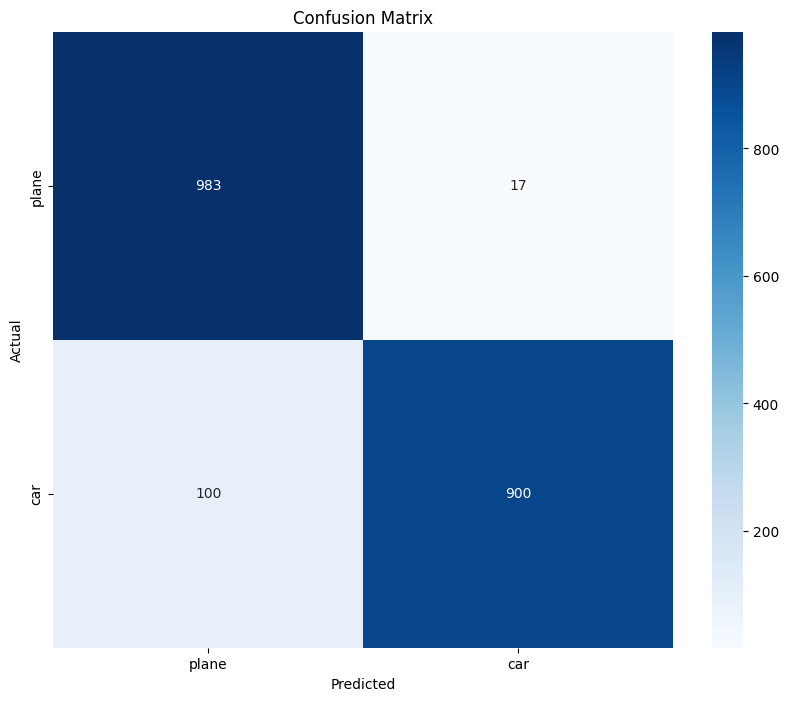

In [10]:
# TODO: Implement model evaluation on the validation set
# Calculate overall accuracy and generate a confusion matrix to understand per-class performance.

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    cm = confusion_matrix(all_labels, all_preds)
    return accuracy, cm, all_preds, all_labels
accuracy, cm, predictions, true_labels = evaluate_model(model, val_loader)
print(f'Final Test Accuracy: {accuracy:.4f}')
# Define class names (if not already in scope)
classes = ('plane', 'car')

# Now plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

2. Visualize sample predictions alongside ground truth labels.

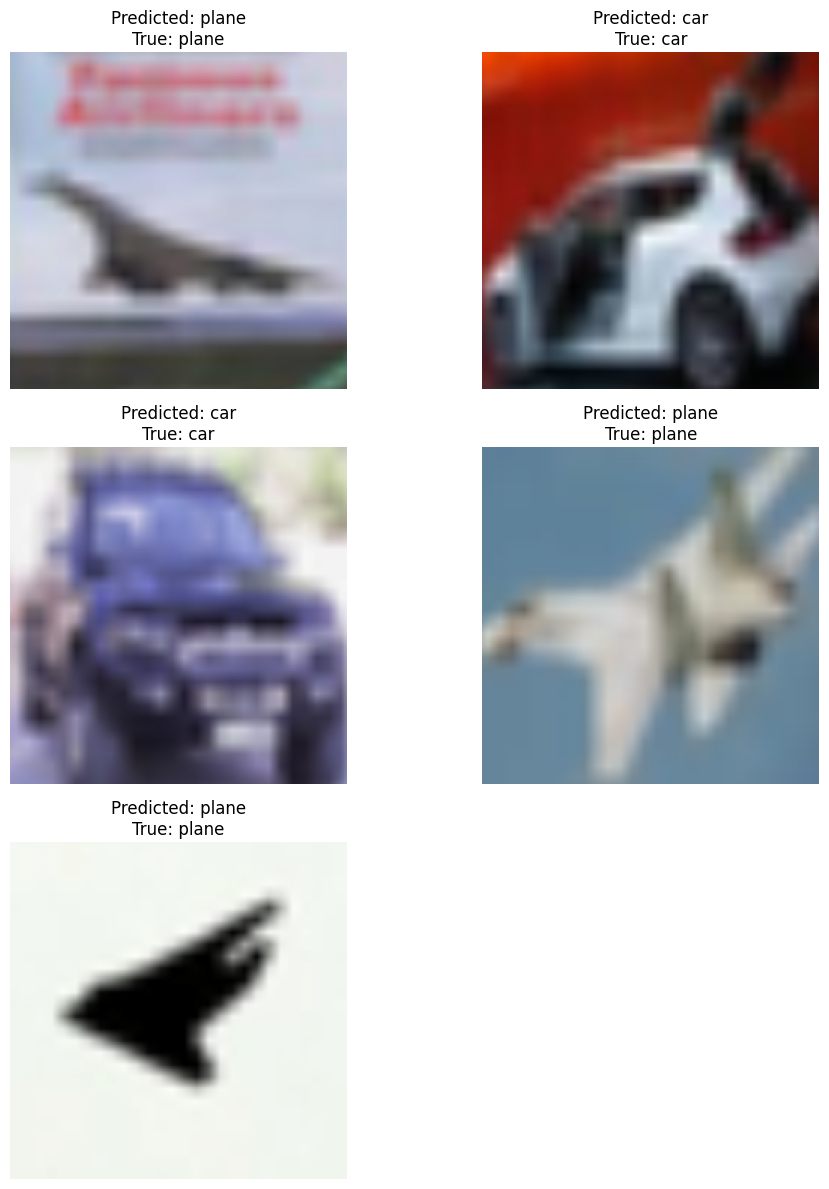

In [11]:
# TODO: Visualize model predictions vs true labels
# Show both correct and incorrect predictions

def visualize_predictions(model, dataloader, classes, num_images=5):
    was_training = model.training
    model.eval()
    images_so_far = 0
    cols = 2
    rows = math.ceil(num_images / cols)

    fig = plt.figure(figsize=(cols * 5, rows * 4))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.show()
                    return

                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {classes[preds[j]]}\nTrue: {classes[labels[j]]}')

                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)

    model.train(mode=was_training)
    plt.tight_layout()
    plt.show()

# Visualize model predictions
visualize_predictions(model, val_loader, classes)

3. Compare the fine-tuned model performance with a baseline (e.g., random guessing).

**💡 Tip:** Use a confusion matrix to identify which classes the model struggles with most.

**⚙️ Test Your Work:**

- Generate a report with overall accuracy and visualize the confusion matrix
- Create visualization showing correctly and incorrectly classified images

## ✅ Success Checklist
- Pre-trained model successfully loaded and inspected
- Feature extraction layers properly frozen (requires_grad = False)
- Classifier layer replaced to match the target dataset classes
- Dataset correctly loaded with appropriate transformations
- Training loop implementation shows decreasing loss and increasing accuracy
- Model evaluation demonstrates significant improvement over random chance
- Sample predictions successfully visualized and analyzed

## 🔍 Common Issues & Solutions
**Problem:** Model doesn't seem to be learning (accuracy stays low) **Solution:** Check that only the classifier is trainable and verify the learning rate isn't too small.

**Problem:** Runtime errors related to tensor dimensions **Solution:** Ensure input image dimensions match what the pre-trained model expects (typically 224×224 for ImageNet models).

**Problem:** Out of memory errors during training **Solution:** Reduce batch size or use a lighter pre-trained model (like MobileNet instead of ResNet).

**Problem:** Overfitting occurs quickly **Solution:** Implement data augmentation in training transforms and consider adding dropout to the classifier.

## 🔑 Key Points
- Transfer learning significantly reduces training time and data requirements
- Freezing feature extraction layers preserves valuable pre-trained knowledge
- The classifier layer needs to be replaced to match your specific task
- Fine-tuning requires careful parameter selection (learning rate, epochs) to be effective
- ImageNet pre-trained models expect specific normalization values and input sizes

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a referance solution</strong></summary>    
    
```python
    
# Task 1: Set up the Environment and Load the Pre-trained Model
    
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math # Import math for ceil
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")
    
# Use torchvision.models.resnet18() with pretrained=True
model = models.resnet18(pretrained=True)
print(model)
print(model.fc)

# Task 2: Freeze Features and Modify the Classifier
   
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)


# Move model to device
model = model.to(device)
    
# Task 3: Prepare Your Dataset
    
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transforms['train'])
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transforms['val'])

train_idx = torch.tensor(train_dataset.targets) < 2
val_idx = torch.tensor(val_dataset.targets) < 2

train_dataset.data = train_dataset.data[train_idx]
train_dataset.targets = torch.tensor(train_dataset.targets)[train_idx].tolist()

val_dataset.data = val_dataset.data[val_idx]
val_dataset.targets = torch.tensor(val_dataset.targets)[val_idx].tolist()

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# Task 4: Implement the Training Loop

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(val_dataset)
        epoch_acc = running_corrects.double() / len(val_dataset)
        print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')
        
        print()

    print(f'Best val Acc: {best_acc:.4f}')
    return model

# Train the model
model = train_model(model, criterion, optimizer, num_epochs=10)
    
# Task 5: Evaluate the Fine-tuned Model
    
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    cm = confusion_matrix(all_labels, all_preds)
    return accuracy, cm, all_preds, all_labels
accuracy, cm, predictions, true_labels = evaluate_model(model, val_loader)
print(f'Final Test Accuracy: {accuracy:.4f}')
# Define class names (if not already in scope)
classes = ('plane', 'car')

# Now plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


def visualize_predictions(model, dataloader, classes, num_images=5):
    was_training = model.training
    model.eval()
    images_so_far = 0
    cols = 2
    rows = math.ceil(num_images / cols)
    
    fig = plt.figure(figsize=(cols * 5, rows * 4))
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size(0)):
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.show()
                    return
                
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {classes[preds[j]]}\nTrue: {classes[labels[j]]}')
                
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)
    
    model.train(mode=was_training)
    plt.tight_layout()
    plt.show()

# Visualize model predictions
visualize_predictions(model, val_loader, classes)
```    